In [1]:
from simple_neural_mpc.controllers import MPC
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.simulation.trajectory import Circle
from simple_neural_mpc.simulation.trajectory_tracking import (
    TrajectoryTrackingSimulation,
)
from simple_neural_mpc.utils import load_config, project_root

In [2]:
reference = Circle(freq=0.1)
root = project_root()
robot = Unicycle()

In [3]:
controller = MPC(robot, to_generate=True)


got cost_type EXTERNAL for cost_type_e, hessian_approx: 'GAUSS_NEWTON'.
With this setting, acados will proceed computing the exact Hessian for the cost term and no Hessian contribution from constraints and dynamics.
If the external cost is a linear least squares cost, this coincides with the Gauss-Newton Hessian.
Note: There is also the option to use the external cost module with a numerical Hessian approximation (see `ext_cost_num_hess`).
OR the option to provide a symbolic custom Hessian approximation (see `cost_expr_ext_cost_custom_hess`).



make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o acados_solver_unicycle.o acados_solver_unicycle.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_expl_ode_fun.o unicycle_model/unicycle_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_expl_vde_forw.o unicycle_model/unicycle_expl_vde_forw.c


In file included from /home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1913,
                 from /home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1230:
/home/neverorfrog/code/simple_neural_mpc/.pixi/envs/default/lib/python3.11/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/neverorfrog/code/mpc-libs/acados/lib \
acados_ocp_solver_pyx.o \
/home/neverorfrog/code/simple_neural_mpc/simple_neural_mpc/scripts/acados_generated_files/c_generated_code/libacados_ocp_solver_unicycle.so \
-L/home/neverorfrog/code/mpc-libs/acados/lib -lacados -lhpipm -lblasfeo -lm


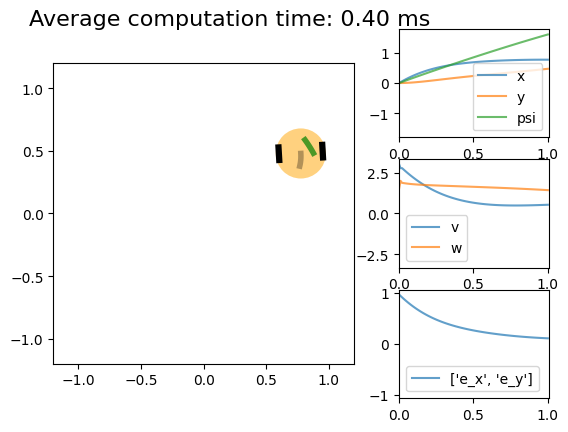

In [4]:
simulation = TrajectoryTrackingSimulation("fbl", robot, controller, reference)
simulation.run(N=100, animate=True, save=False)